In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
try:
    import open3d as o3d
except ImportError as e:
    raise SystemExit(
        "This script needs the open3d package:\n"
        "    pip install open3d\n"
        "and then run it again."
    ) from e

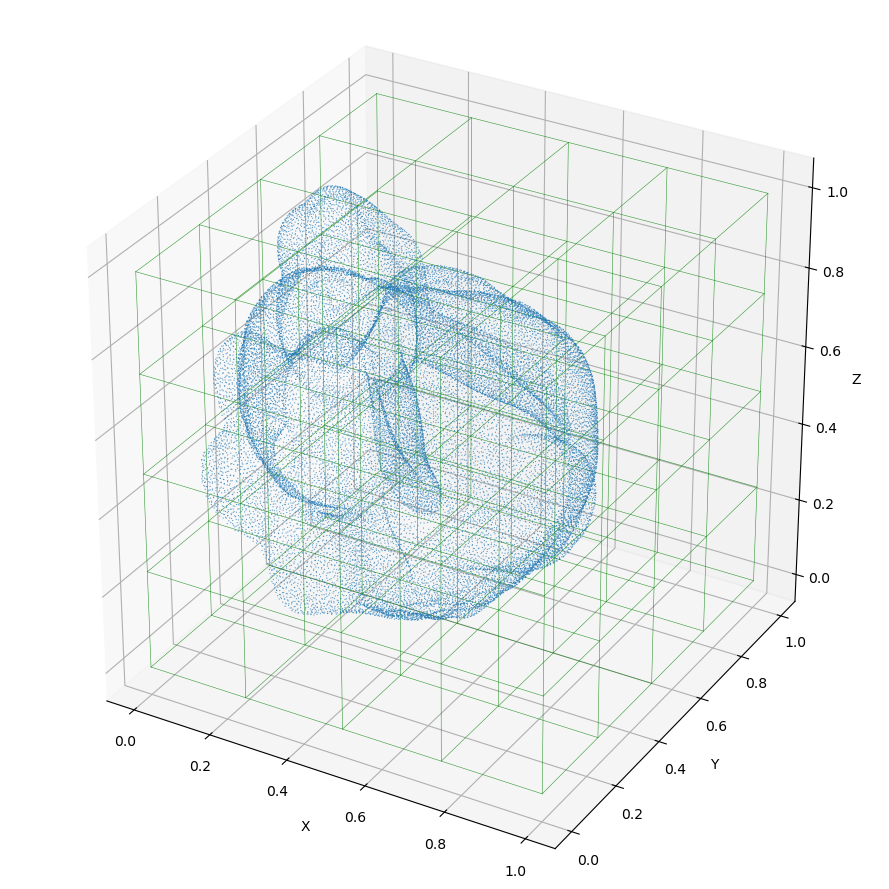

In [6]:
mesh_path = o3d.data.BunnyMesh().path
mesh       = o3d.io.read_triangle_mesh(mesh_path)
pcd        = mesh.sample_points_poisson_disk(number_of_points=30_000,
                                             init_factor=5)

points = np.asarray(pcd.points)                
mins, maxs = points.min(0), points.max(0)
span       = np.where(maxs == mins, 1, maxs - mins) 
points     = (points - mins) / span               

fig = plt.figure(figsize=(9, 9))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           s=0.8, alpha=0.7, linewidths=0)

grid_divs = 4
ticks = np.linspace(0, 1, grid_divs + 1)

for x in ticks:
    for y in ticks:
        ax.plot([x, x], [y, y], [0, 1], lw=0.4, color='g', alpha=0.8)
for x in ticks:
    for z in ticks:
        ax.plot([x, x], [0, 1], [z, z], lw=0.4, color='g', alpha=0.8)
for y in ticks:
    for z in ticks:
        ax.plot([0, 1], [y, y], [z, z], lw=0.4, color='g', alpha=0.8)

ax.set_xlabel("X"), ax.set_ylabel("Y"), ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])     
plt.tight_layout()
plt.show()
